In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
output_folder = pathlib.Path("../../data/outputs_nosync/outputs_leaf/")
prediction_runs = [fol for fol in output_folder.iterdir() if fol.is_dir()]
prediction_runs

[PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_f_1000')]

In [3]:
def read_csv_files(folder_list: list[pathlib.Path], file_name: str, reindex: bool = True):
    df_list = []
    for folder in folder_list:
        file_path = folder / file_name
        df = pd.read_csv(file_path, index_col=0)
        df_list.append(df)
    df_concat = pd.concat(df_list)
    if reindex:
        df_concat.index = list(range(df_concat.shape[0])) # type: ignore
    return df_concat

In [4]:
scores_df = read_csv_files(prediction_runs, "all_feat_scores_data.csv", reindex=True)
scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef,class_0,class_1,feature,run_id
0,Oxalate,leaf_biolog,0.983333,0.990741,0.923077,0.857143,1.000000,0.917208,181,19,cluster30,biolog_mutual_info_1000
1,Mannitol,leaf_biolog,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,111,92,cluster30,biolog_mutual_info_1000
2,Pyruvate,leaf_biolog,0.866667,0.820513,0.904762,0.844444,0.974359,0.706099,69,128,cluster30,biolog_mutual_info_1000
3,Succite,leaf_biolog,0.967213,0.955797,0.978261,0.978261,0.978261,0.911594,48,153,cluster30,biolog_mutual_info_1000
4,Histidine,leaf_biolog,0.967213,0.933333,0.928571,1.000000,0.866667,0.911348,151,51,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
2875,Sucrose,leaf_biolog,0.862069,0.820155,0.906977,0.906977,0.906977,0.640310,51,142,uniref90,biolog_f_1000
2876,Leucine,leaf_biolog,0.915254,0.772727,0.705882,1.000000,0.545455,0.702849,158,38,uniref90,biolog_f_1000
2877,Tyrosine,leaf_biolog,0.915254,0.861111,0.838710,1.000000,0.722222,0.802322,135,59,uniref90,biolog_f_1000
2878,Maltose,leaf_biolog,0.933333,0.913043,0.948718,0.902439,1.000000,0.863419,74,123,uniref90,biolog_f_1000


In [5]:
cv_scores_df = read_csv_files(prediction_runs, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,1,cluster30,biolog_mutual_info_1000
1,0.950000,0.972222,0.666667,1.000000,0.800000,0.958333,0.793492,Oxalate,leaf_biolog,2,cluster30,biolog_mutual_info_1000
2,0.950000,0.861111,0.750000,0.750000,0.750000,0.972222,0.722222,Oxalate,leaf_biolog,3,cluster30,biolog_mutual_info_1000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,leaf_biolog,4,cluster30,biolog_mutual_info_1000
4,0.975000,0.875000,1.000000,0.750000,0.857143,1.000000,0.854242,Oxalate,leaf_biolog,5,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
14395,0.875000,0.772727,1.000000,0.545455,0.705882,0.962382,0.682086,myo_inositol,leaf_biolog,1,uniref90,biolog_f_1000
14396,0.825000,0.732143,0.857143,0.500000,0.631579,0.922619,0.559950,myo_inositol,leaf_biolog,2,uniref90,biolog_f_1000
14397,0.800000,0.738095,0.700000,0.583333,0.636364,0.901786,0.503953,myo_inositol,leaf_biolog,3,uniref90,biolog_f_1000
14398,0.871795,0.772727,1.000000,0.545455,0.705882,0.944805,0.680301,myo_inositol,leaf_biolog,4,uniref90,biolog_f_1000


In [6]:
cv_features_df = read_csv_files(prediction_runs, "all_feat_cv_features_data.csv", reindex=True)
cv_features_df

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_16,feat_17,feat_18,feat_19,feat_20,fold_num,feature,run_id,name,category
0,607_914,1152_3516,210_2137,967_3922,783_204,189_2758,662_4244,1218_2348,206_3640,1332_352,...,1341_2914,892_614,1250_1766,1342_79,77_2131,1,cluster30,biolog_mutual_info_1000,Oxalate,leaf_biolog
1,607_914,1152_3516,189_2758,1250_1766,967_3922,206_3640,783_204,261_2789,373_3497,1395_5686,...,373_3153,502_1172,1185_1097,1218_2348,219_5635,2,cluster30,biolog_mutual_info_1000,Oxalate,leaf_biolog
2,607_914,1152_3516,1250_1766,206_3640,967_3922,1332_352,189_2758,1218_2348,783_204,373_3497,...,662_4244,486_1354,575_3065,1395_5686,581_880,3,cluster30,biolog_mutual_info_1000,Oxalate,leaf_biolog
3,607_914,1152_3516,1218_2348,137_3641,1332_352,967_3922,783_204,1341_2914,654_4389,930_3124,...,624_2748,831_2517,748_2400,203_3442,575_3065,4,cluster30,biolog_mutual_info_1000,Oxalate,leaf_biolog
4,311_702,189_2758,206_3640,203_3442,373_3153,930_3124,494_1504,1395_5686,1152_3516,1067_2598,...,930_1133,1086_4448,8_5998,494_1367,630_1792,5,cluster30,biolog_mutual_info_1000,Oxalate,leaf_biolog
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,UniRef90_A0A0Q5AYH0,UniRef90_N0E4M9,UniRef90_Q8UE21,UniRef90_A0A0Q5ADA6,UniRef90_UPI001A95C457,UniRef90_A0A031FXK8,UniRef90_Q9FD95,UniRef90_Q884C2,UniRef90_Q82DN5,UniRef90_A0A087NG30,...,UniRef90_A0A4Q3B7U8,UniRef90_A0A0S9RBV2,UniRef90_A0A0Q4INA4,UniRef90_A0A1G7RBM9,UniRef90_A0A031HPE3,1,uniref90,biolog_f_1000,myo_inositol,leaf_biolog
14396,UniRef90_Q9FD95,UniRef90_A0A0Q5AYH0,UniRef90_N0E4M9,UniRef90_UPI001A95C457,UniRef90_Q5YUX4,UniRef90_C3MD65,UniRef90_A0A0Q5ADA6,UniRef90_Q1MIE3,UniRef90_A0JWN0,UniRef90_A0A1R4G0R4,...,UniRef90_Q8UE21,UniRef90_A0A0P0E4K7,UniRef90_P14129,UniRef90_Q884C2,UniRef90_Q889Y0,2,uniref90,biolog_f_1000,myo_inositol,leaf_biolog
14397,UniRef90_Q9FD95,UniRef90_UPI001A95C457,UniRef90_A0A0Q5AYH0,UniRef90_A0A031FXK8,UniRef90_A0JWN0,UniRef90_Q1MIE3,UniRef90_A0A0N0E7M4,UniRef90_A0A0Q5ADA6,UniRef90_A0A4V1FBF9,UniRef90_Q8UE21,...,UniRef90_A0A2E1YYP2,UniRef90_A0A099JVA2,UniRef90_Q52955,UniRef90_C3MD65,UniRef90_A0A0U4CMG2,3,uniref90,biolog_f_1000,myo_inositol,leaf_biolog
14398,UniRef90_A0A0Q5AYH0,UniRef90_N0E4M9,UniRef90_Q9FD95,UniRef90_UPI001A95C457,UniRef90_N6VGU2,UniRef90_C3MB68,UniRef90_A0A4Q3B7U8,UniRef90_Q2N9A5,UniRef90_Q5YUX4,UniRef90_A0A087NG30,...,UniRef90_C3K116,UniRef90_Q1MIE3,UniRef90_W1S6A8,UniRef90_A0A0S9QZS4,UniRef90_A0A0P0DKD6,4,uniref90,biolog_f_1000,myo_inositol,leaf_biolog


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

Plot std of metrics in each cross validation

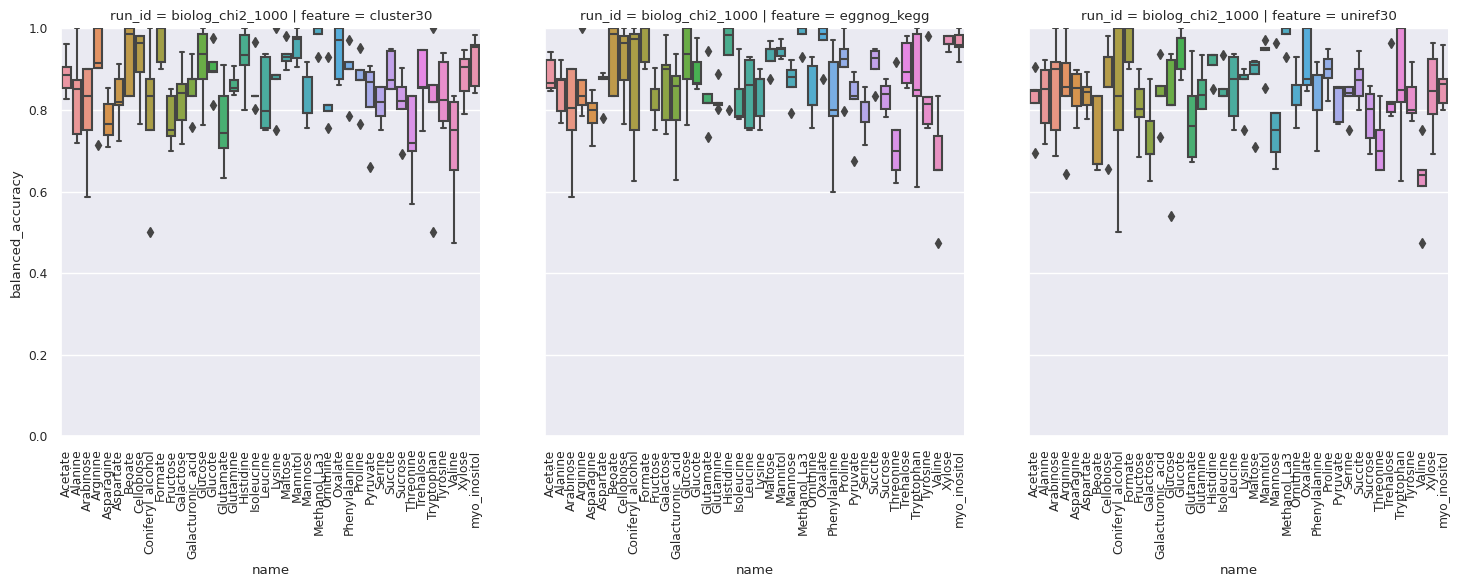

In [26]:
plot_data = cv_scores_df[(cv_scores_df.feature.isin(["eggnog_kegg", "cluster30", "uniref30"])) & (cv_scores_df.run_id.isin(["biolog_chi2_1000"]))]
name_order = plot_data.groupby(by=["name"])["balanced_accuracy"].mean().reset_index().name
g = sns.catplot(data=plot_data, x="name", y="balanced_accuracy", kind="box", row="run_id", col="feature", order=name_order)
plt.ylim(0.0, 1.0)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

In [22]:
def common_features(group):
    df = group.drop(["fold_num", "category", "feature", "run_id", "name"], axis=1)
    n = df.shape[0]
    m = df.shape[1]
    feature_list = []
    for i in range(n):
        feature_list.append(set(df.iloc[i]))
    common_features = set.intersection(*feature_list)
    return len(common_features) / m * 100

/tmp/ipykernel_104278/580804665.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_data = cv_features_df[(cv_features_df.feature == "rast") & (cv_features_df.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"]))].groupby(by=["run_id", "name"]).apply(common_features).reset_index()


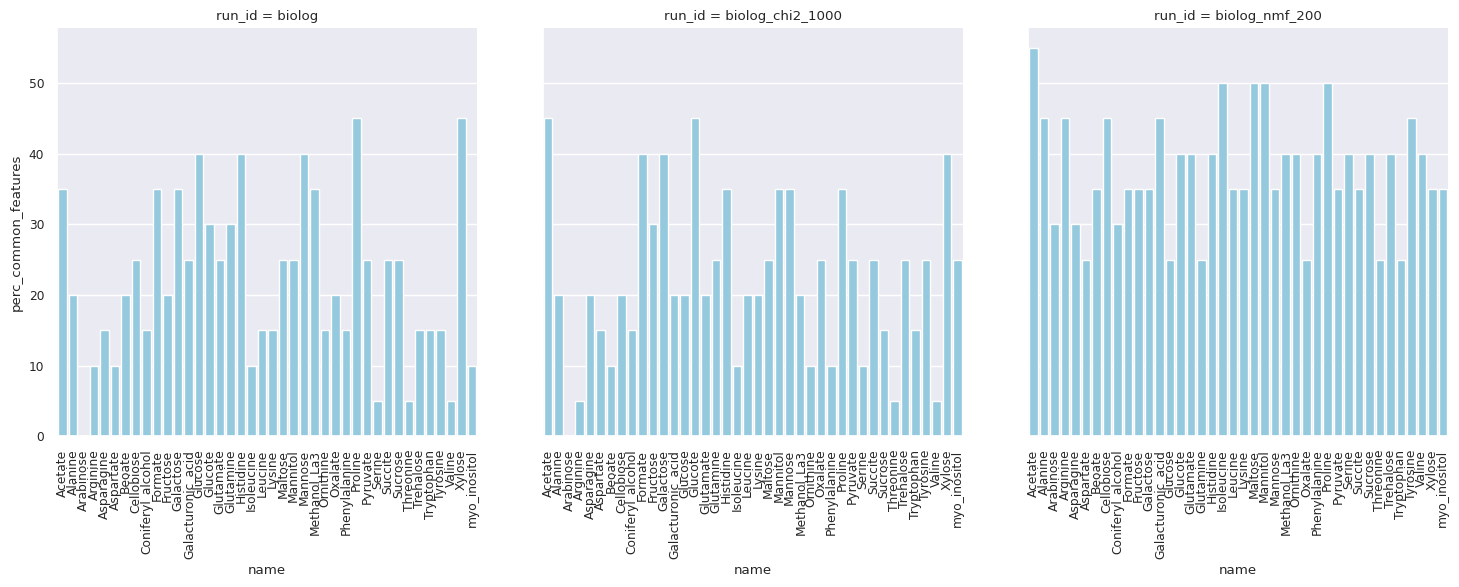

In [24]:
plot_data = cv_features_df[(cv_features_df.feature == "rast") & (cv_features_df.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"]))].groupby(by=["run_id", "name"]).apply(common_features).reset_index()
plot_data.columns = ["run_id", "name", "perc_common_features"]
g = sns.catplot(data=plot_data, x="name", y="perc_common_features", kind="bar", col="run_id", col_wrap=3, color="skyblue", order=name_order)
# plt.ylim(0, 1)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

In [11]:
cv_scores_melt = cv_scores_df.melt(id_vars=["run_id", "name", "feature", "fold_num", "category"], value_vars=["accuracy", "balanced_accuracy", "f1", "precision", "recall", "matthews_corrcoef"], var_name="metric")
cv_scores_melt

,run_id,name,feature,fold_num,category,metric,value
0,biolog_mutual_info_1000,Oxalate,cluster30,1,leaf_biolog,accuracy,1.000000
1,biolog_mutual_info_1000,Oxalate,cluster30,2,leaf_biolog,accuracy,0.950000
2,biolog_mutual_info_1000,Oxalate,cluster30,3,leaf_biolog,accuracy,0.950000
3,biolog_mutual_info_1000,Oxalate,cluster30,4,leaf_biolog,accuracy,1.000000
4,biolog_mutual_info_1000,Oxalate,cluster30,5,leaf_biolog,accuracy,0.975000
...,...,...,...,...,...,...,...
86395,biolog_f_1000,myo_inositol,uniref90,1,leaf_biolog,matthews_corrcoef,0.682086
86396,biolog_f_1000,myo_inositol,uniref90,2,leaf_biolog,matthews_corrcoef,0.559950
86397,biolog_f_1000,myo_inositol,uniref90,3,leaf_biolog,matthews_corrcoef,0.503953
86398,biolog_f_1000,myo_inositol,uniref90,4,leaf_biolog,matthews_corrcoef,0.680301


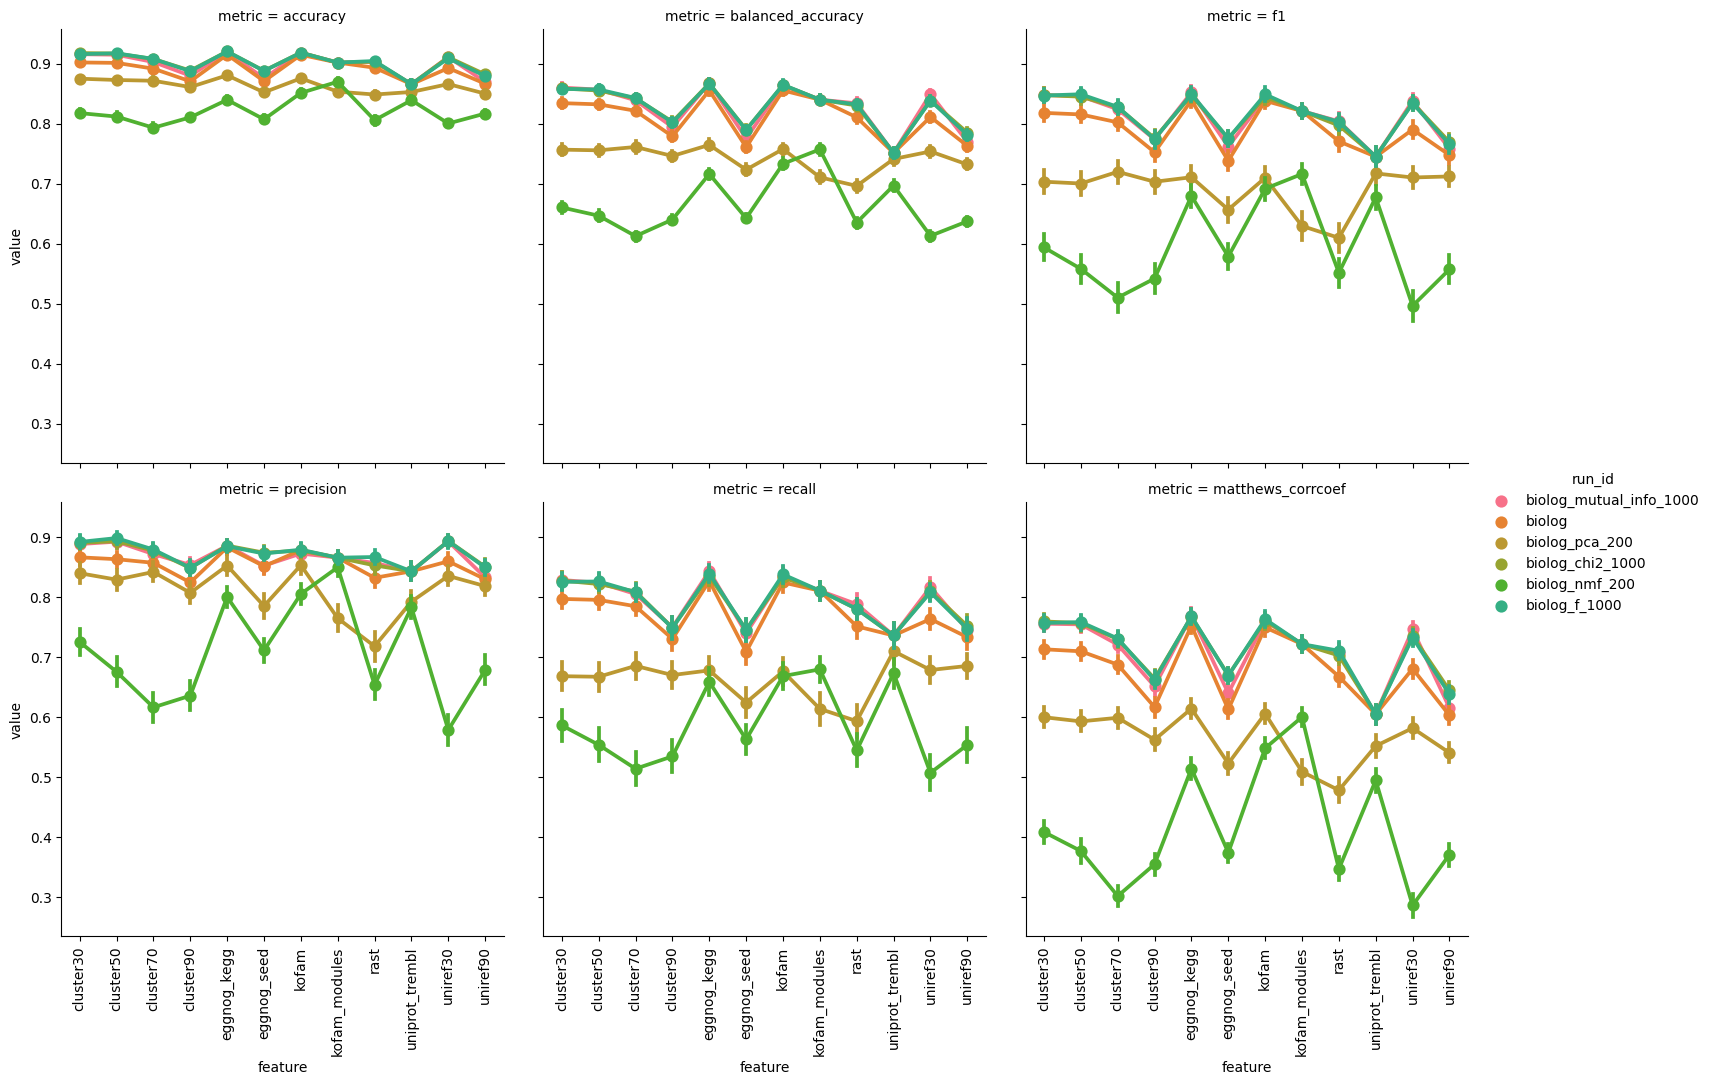

In [12]:
plot_data = cv_scores_melt
palette = sns.color_palette("husl", 12)
g = sns.catplot(data=plot_data, x="feature", y="value", errorbar="se", kind="point", col="metric", col_wrap=3, hue="run_id", palette=palette)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

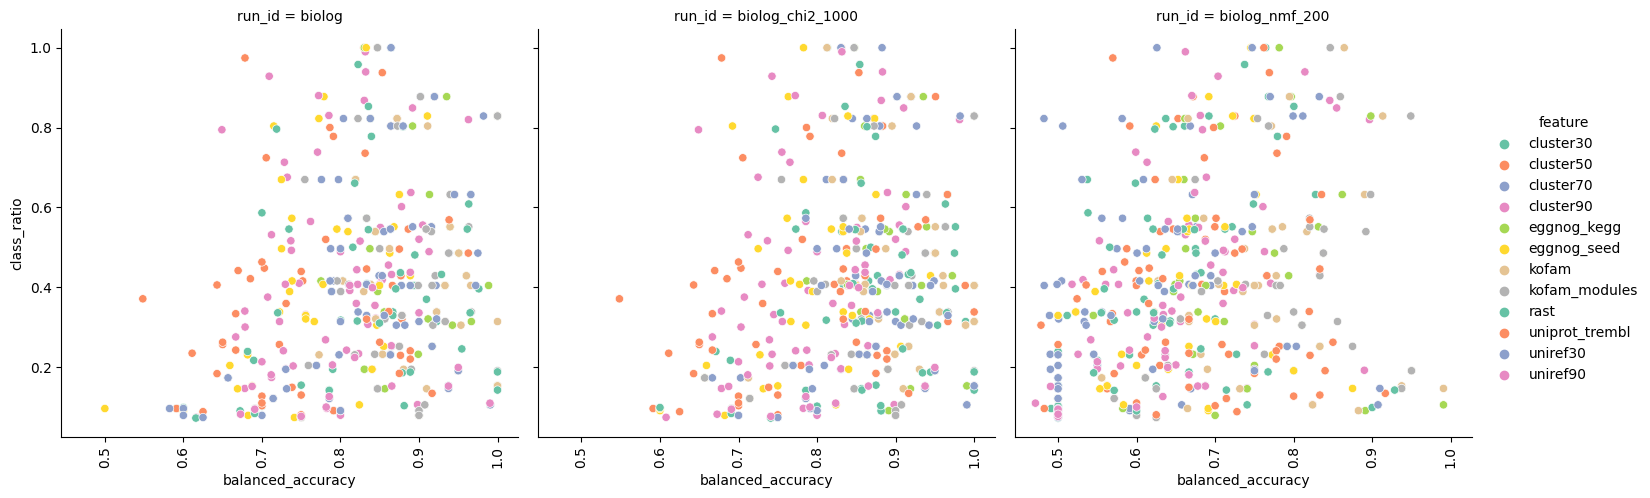

In [13]:
plot_data = scores_df.copy()
plot_data = plot_data[plot_data.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"])]
plot_data["class_ratio"] = plot_data.apply(lambda x: min(x["class_1"], x["class_0"]) / max(x["class_1"], x["class_0"]), axis=1)
g = sns.relplot(data=plot_data, x="balanced_accuracy", y="class_ratio", kind="scatter", col="run_id", col_wrap=3, hue="feature", palette="Set2")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

In [14]:
cv_scores_df.groupby(by=["run_id", "feature", "name"])["balanced_accuracy"].mean().reset_index().sort_values(by="balanced_accuracy", ascending=False).head(10)

,run_id,feature,name,balanced_accuracy
1264,biolog_f_1000,kofam_modules,Methanol_La3,0.996970
304,biolog,kofam_modules,Methanol_La3,0.996970
784,biolog_chi2_1000,kofam_modules,Methanol_La3,0.996970
1744,biolog_mutual_info_1000,kofam_modules,Methanol_La3,0.996970
824,biolog_chi2_1000,rast,Methanol_La3,0.996875
344,biolog,rast,Methanol_La3,0.996875
1304,biolog_f_1000,rast,Methanol_La3,0.996875
1784,biolog_mutual_info_1000,rast,Methanol_La3,0.996875
1584,biolog_mutual_info_1000,cluster90,Methanol_La3,0.985714
2224,biolog_nmf_200,kofam_modules,Methanol_La3,0.985714


In [15]:
cv_bac_scores = cv_scores_melt[(cv_scores_melt.metric == "balanced_accuracy") & (cv_scores_melt.feature == "rast")].groupby(by=["run_id", "name"])["value"].mean().reset_index().sort_values(by="value", ascending=False).pivot(index="name", columns="run_id", values="value")
cv_bac_scores

run_id,biolog,biolog_chi2_1000,biolog_f_1000,biolog_mutual_info_1000,biolog_nmf_200,biolog_pca_200
name,,,,,,
Acetate,0.874051,0.877103,0.873256,0.888949,0.674564,0.809641
Alanine,0.843860,0.854386,0.848830,0.854386,0.758480,0.761988
Arabinose,0.761176,0.761176,0.764118,0.761176,0.665000,0.707059
Arginine,0.723958,0.740625,0.723958,0.723958,0.554261,0.516667
Asparagine,0.742139,0.773190,0.777952,0.772952,0.597213,0.664881
Aspartate,0.768874,0.811299,0.789870,0.795065,0.592987,0.714892
Beoate,0.752778,0.722222,0.719444,0.822222,0.497222,0.566667
Cellobiose,0.907051,0.894551,0.906410,0.890385,0.706777,0.834203
Coniferyl_alcohol,0.758333,0.761111,0.788889,0.788889,0.525000,0.591667


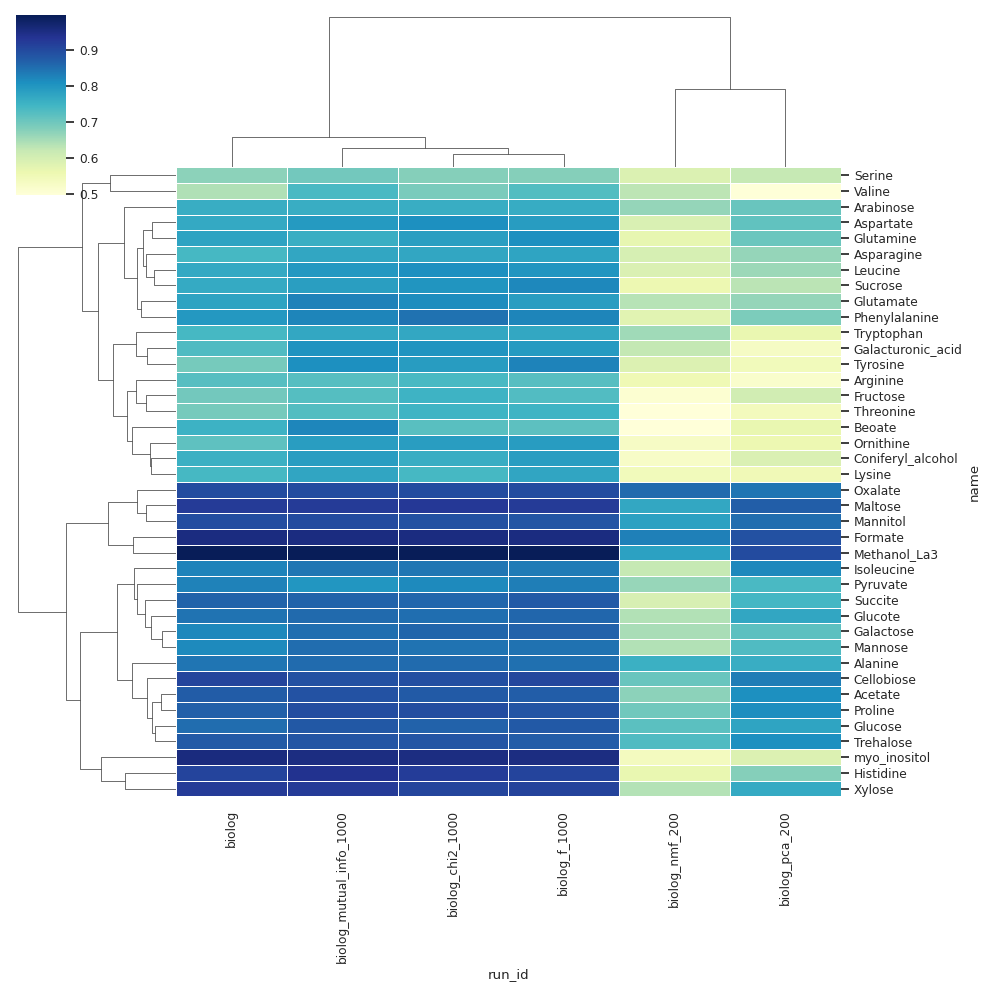

In [16]:
plot_data = cv_bac_scores
sns.set(font_scale=0.8)
sns.clustermap(plot_data,  linewidths=.5, cmap="YlGnBu", yticklabels=1)

In [17]:
mean_scores_df = (cv_scores_df
    .drop(["category", "fold_num"], axis=1)
    .groupby(by=["run_id", "feature", "name"])
    .mean()
    .reset_index()
)

Best feature across all runs and phenotypes

In [18]:
mean_scores_df.drop(["run_id", "name"], axis=1).groupby(by="feature").mean().sort_values(by="balanced_accuracy", ascending=False)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef
feature,,,,,,,
kofam,0.899394,0.823177,0.860576,0.778593,0.795986,0.934849,0.697423
eggnog_kegg,0.899262,0.822865,0.864920,0.779753,0.796207,0.933107,0.697010
cluster30,0.890628,0.804648,0.849942,0.755044,0.776140,0.920886,0.665101
kofam_modules,0.888384,0.804577,0.845804,0.755595,0.771575,0.928191,0.665489
cluster50,0.889138,0.800493,0.841552,0.747606,0.768846,0.917871,0.657706
cluster70,0.879113,0.786466,0.823546,0.733992,0.751824,0.909005,0.627849
uniref30,0.881577,0.784009,0.825147,0.730184,0.750524,0.910848,0.626609
rast,0.876363,0.772998,0.796330,0.705853,0.722532,0.905822,0.601739
cluster90,0.866308,0.760705,0.802607,0.696571,0.720135,0.899002,0.584712


Best phenotype across all runs and features

In [19]:
mean_scores_df.drop(["run_id", "feature"], axis=1).groupby(by="name").mean().sort_values(by="balanced_accuracy", ascending=False)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef
name,,,,,,,
Methanol_La3,0.977797,0.945010,0.977651,0.894643,0.920958,0.987094,0.917945
Formate,0.983341,0.939803,0.992824,0.880556,0.925494,0.982356,0.923154
Oxalate,0.966629,0.899134,0.857791,0.815278,0.811544,0.974719,0.808606
Mannitol,0.886003,0.885587,0.881185,0.876990,0.872314,0.953146,0.778799
Maltose,0.897813,0.882134,0.900521,0.948929,0.921214,0.962370,0.786403
Cellobiose,0.888375,0.857294,0.883789,0.963388,0.919702,0.942782,0.754218
Glucose,0.933270,0.853448,0.936186,0.986885,0.960058,0.946358,0.772528
Trehalose,0.868982,0.832001,0.865954,0.954638,0.905769,0.932029,0.710923
Proline,0.829862,0.828746,0.833032,0.809568,0.812396,0.920543,0.667764


Best run across all phenotypes and features

In [20]:
mean_scores_df.drop(["name", "feature"], axis=1).groupby(by="run_id").mean().sort_values(by="balanced_accuracy", ascending=False)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef
run_id,,,,,,,
biolog_chi2_1000,0.901744,0.827107,0.870641,0.792051,0.810763,0.940858,0.709287
biolog_f_1000,0.901279,0.826959,0.872360,0.792316,0.811653,0.940806,0.709254
biolog_mutual_info_1000,0.898125,0.825125,0.866928,0.793077,0.809512,0.933970,0.703397
biolog,0.890507,0.809505,0.854104,0.771417,0.789750,0.924544,0.676158
biolog_pca_200,0.863251,0.741504,0.811074,0.662046,0.690121,0.892580,0.562661
biolog_nmf_200,0.821908,0.665802,0.708961,0.585926,0.595850,0.826154,0.414192
